In [7]:
import pandas as pd
import re

In [8]:
# Path file log
file_path = "old.log"

# Pola regex untuk memecah log Apache
log_pattern = r'(\S+) - - \[(.*?)\] "(.*?)" (\d+) (\d+|-) "(.*?)" "(.*?)"'

# Menyimpan hasil parsing
parsed_logs = []

# Membaca file log baris demi baris
with open(file_path, 'r') as file:
    for line in file:
        match = re.match(log_pattern, line)
        if match:
            parsed_logs.append(match.groups())

# Konversi ke DataFrame Pandas
columns = [
    "IP_Address", "Timestamp", "Request", "Status_Code", 
    "Response_Size", "Referrer", "User_Agent"
]
log_data = pd.DataFrame(parsed_logs, columns=columns)

# Konversi tipe data numerik
log_data["Status_Code"] = pd.to_numeric(log_data["Status_Code"], errors='coerce')
log_data["Response_Size"] = pd.to_numeric(log_data["Response_Size"], errors='coerce')

# Menampilkan data yang dihasilkan
print(log_data.head())

      IP_Address                   Timestamp  \
0   66.249.79.63  16/Dec/2022:17:04:10 +0700   
1  10.220.34.198  16/Dec/2022:17:04:12 +0700   
2  10.220.34.198  16/Dec/2022:17:05:16 +0700   
3  114.5.105.122  16/Dec/2022:17:06:07 +0700   
4  114.5.105.122  16/Dec/2022:17:06:08 +0700   

                                             Request  Status_Code  \
0                           GET /robots.txt HTTP/1.0          404   
1                                     GET / HTTP/1.0          200   
2                                     GET / HTTP/1.0          200   
3                                     GET / HTTP/1.0          200   
4  GET /wp-content/plugins/elementor/assets/lib/e...          200   

   Response_Size                     Referrer  \
0            146                            -   
1            138                            -   
2         665508                            -   
3         665508                            -   
4          92444  https://ittelkom-sby.ac.id/   

 

In [10]:
log_data.head(20)

,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent
0,66.249.79.63,16/Dec/2022:17:04:10 +0700,GET /robots.txt HTTP/1.0,404,146,-,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...
1,10.220.34.198,16/Dec/2022:17:04:12 +0700,GET / HTTP/1.0,200,138,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...
2,10.220.34.198,16/Dec/2022:17:05:16 +0700,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...
3,114.5.105.122,16/Dec/2022:17:06:07 +0700,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
4,114.5.105.122,16/Dec/2022:17:06:08 +0700,GET /wp-content/plugins/elementor/assets/lib/e...,200,92444,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
5,114.5.105.122,16/Dec/2022:17:06:08 +0700,GET /wp-content/plugins/elementor/assets/lib/f...,200,78196,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
6,114.5.105.122,16/Dec/2022:17:06:08 +0700,GET /wp-content/plugins/happy-elementor-addons...,200,740,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
7,114.5.105.122,16/Dec/2022:17:06:09 +0700,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
8,90.153.58.75,16/Dec/2022:17:06:12 +0700,GET / HTTP/1.0,200,665508,https://www.google.com/,Mozilla/5.0 (Linux; Android 10; ELE-L29) Apple...
9,10.220.34.198,16/Dec/2022:17:06:13 +0700,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...


In [11]:
from datetime import datetime

# Function to convert timestamp
def convert_timestamp(timestamp):
    # Parse the original timestamp format
    dt_object = datetime.strptime(timestamp, '%d/%b/%Y:%H:%M:%S %z')
    # Reformat to the desired format
    return dt_object.strftime('%d/%m/%Y %H:%M:%S')

# Apply the conversion to the Timestamp column
log_data['Timestamp'] = log_data['Timestamp'].apply(convert_timestamp)

log_data.head(20)

,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent
0,66.249.79.63,16/12/2022 17:04:10,GET /robots.txt HTTP/1.0,404,146,-,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...
1,10.220.34.198,16/12/2022 17:04:12,GET / HTTP/1.0,200,138,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...
2,10.220.34.198,16/12/2022 17:05:16,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...
3,114.5.105.122,16/12/2022 17:06:07,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
4,114.5.105.122,16/12/2022 17:06:08,GET /wp-content/plugins/elementor/assets/lib/e...,200,92444,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
5,114.5.105.122,16/12/2022 17:06:08,GET /wp-content/plugins/elementor/assets/lib/f...,200,78196,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
6,114.5.105.122,16/12/2022 17:06:08,GET /wp-content/plugins/happy-elementor-addons...,200,740,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
7,114.5.105.122,16/12/2022 17:06:09,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
8,90.153.58.75,16/12/2022 17:06:12,GET / HTTP/1.0,200,665508,https://www.google.com/,Mozilla/5.0 (Linux; Android 10; ELE-L29) Apple...
9,10.220.34.198,16/12/2022 17:06:13,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...


In [14]:
log_data. to_csv('oldlogs.csv', index=False)

In [15]:
dataset = pd.read_csv('oldlogs.csv')
dataset

,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent
0,66.249.79.63,16/12/2022 17:04:10,GET /robots.txt HTTP/1.0,404,146,-,Mozilla/5.0 (compatible; Googlebot/2.1; +http:...
1,10.220.34.198,16/12/2022 17:04:12,GET / HTTP/1.0,200,138,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...
2,10.220.34.198,16/12/2022 17:05:16,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (compatible; PRTG Network Monitor ...
3,114.5.105.122,16/12/2022 17:06:07,GET / HTTP/1.0,200,665508,-,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
4,114.5.105.122,16/12/2022 17:06:08,GET /wp-content/plugins/elementor/assets/lib/e...,200,92444,https://ittelkom-sby.ac.id/,Mozilla/5.0 (iPhone; CPU iPhone OS 16_1 like M...
...,...,...,...,...,...,...,...
11364746,10.220.5.92,17/09/2024 07:41:14,GET /robots.txt HTTP/1.0,200,176,-,Mozilla/5.0 (compatible;PetalBot;+https://webm...
11364747,10.220.5.92,17/09/2024 07:45:28,GET / HTTP/1.0,301,162,http://www.ittelkom-sby.ac.id,Mozilla/5.0+(compatible; UptimeRobot/2.0; http...
11364748,10.220.5.92,17/09/2024 07:50:28,GET / HTTP/1.0,200,138,http://www.ittelkom-sby.ac.id,Mozilla/5.0+(compatible; UptimeRobot/2.0; http...
11364749,10.220.5.92,17/09/2024 07:55:28,HEAD / HTTP/1.0,200,0,http://www.ittelkom-sby.ac.id,Mozilla/5.0+(compatible; UptimeRobot/2.0; http...


In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Load CSV file
df = dataset

# Convert 'Timestamp' to datetime and extract useful features
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Encode categorical columns
categorical_columns = ['IP_Address', 'Request', 'Referrer', 'User_Agent']
encoder = LabelEncoder()

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col].astype(str))

# Select relevant columns for anomaly detection
features = ['IP_Address', 'hour', 'day_of_week', 'Request', 'Status_Code', 'Response_Size', 'Referrer', 'User_Agent']
X = df[features]

# Standardize the data (important for models like Isolation Forest)
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Apply Isolation Forest for anomaly detection
model = IsolationForest(contamination=0.05)  # adjust contamination as needed (percentage of anomalies)
df['anomaly'] = model.fit_predict(X)

# Mark anomalies with -1 (normal points are labeled as 1)
df['anomaly'] = df['anomaly'].apply(lambda x: 1 if x == 1 else 0)

# Save the result with anomaly labels
df.to_csv('labeled_log_data.csv', index=False)

# Show the first few rows of labeled data
print(df.head())


   IP_Address           Timestamp  Request  Status_Code  Response_Size  \
0       15505 2022-12-16 17:04:10  1236051          404            146   
1       36679 2022-12-16 17:04:12   555557          200            138   
2       36679 2022-12-16 17:05:16   555557          200         665508   
3       53626 2022-12-16 17:06:07   555557          200         665508   
4       53626 2022-12-16 17:06:08  1320396          200          92444   

   Referrer  User_Agent  Hour  Request_Length  Anomaly  Is_Anomaly  hour  \
0     66668      236341    17              24        1       False    17   
1     66668      236736    17              14        1       False    17   
2     66668      236736    17              14        1       False    17   
3     66668      238454    17              14        1       False    17   
4    155216      238454    17              86        1       False    17   

   day_of_week  anomaly  
0            4        1  
1            4        1  
2            4      

In [27]:
display(df[df['Is_Anomaly'] == True], df[df['Is_Anomaly'] == False])

,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent,Hour,Request_Length,Anomaly,Is_Anomaly,hour,day_of_week,anomaly
25,36803,2022-12-16 17:10:29,1292324,499,0,66668,690880,17,201,-1,True,17,4,1
27,36803,2022-12-16 17:10:32,1292274,499,0,66668,690880,17,211,-1,True,17,4,1
28,36803,2022-12-16 17:10:33,1436253,499,0,176811,690880,17,85,-1,True,17,4,0
45,36803,2022-12-16 17:10:56,1436253,499,0,176811,369111,17,85,-1,True,17,4,1
60,36803,2022-12-16 17:11:17,1436253,499,0,176811,596519,17,85,-1,True,17,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11363635,37296,2024-09-17 00:51:50,555557,301,162,144459,239652,0,14,-1,True,0,1,1
11363645,37296,2024-09-17 00:57:15,555557,301,162,144459,239652,0,14,-1,True,0,1,1
11363691,37296,2024-09-17 03:22:34,716473,404,107781,66668,214260,3,116,-1,True,3,1,1
11363797,37296,2024-09-17 05:02:58,1236051,502,150,66668,236341,5,24,-1,True,5,1,1


,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent,Hour,Request_Length,Anomaly,Is_Anomaly,hour,day_of_week,anomaly
0,15505,2022-12-16 17:04:10,1236051,404,146,66668,236341,17,24,1,False,17,4,1
1,36679,2022-12-16 17:04:12,555557,200,138,66668,236736,17,14,1,False,17,4,1
2,36679,2022-12-16 17:05:16,555557,200,665508,66668,236736,17,14,1,False,17,4,1
3,53626,2022-12-16 17:06:07,555557,200,665508,66668,238454,17,14,1,False,17,4,1
4,53626,2022-12-16 17:06:08,1320396,200,92444,155216,238454,17,86,1,False,17,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11364746,37296,2024-09-17 07:41:14,1236051,200,176,66668,236834,7,24,1,False,7,1,1
11364747,37296,2024-09-17 07:45:28,555557,301,162,144459,239652,7,14,1,False,7,1,1
11364748,37296,2024-09-17 07:50:28,555557,200,138,144459,239652,7,14,1,False,7,1,1
11364749,37296,2024-09-17 07:55:28,1350585,200,0,144459,239652,7,15,1,False,7,1,1


In [29]:
# Analyze anomalies by feature
anomaly_data = df[df['Is_Anomaly'] == True]  # Filter anomalies (where anomaly == 0)
normal_data = df[df['Is_Anomaly'] == False]   # Filter normal data (where anomaly == 1)

# Summary statistics for anomalies vs normal data
summary_anomalies = anomaly_data.describe()
summary_normal = normal_data.describe()

print("Summary statistics for anomalies:")
print(summary_anomalies)

print("\n------------------------------------------------------------")
print("\nSummary statistics for normal data:")
print(summary_normal)


Summary statistics for anomalies:
         IP_Address                      Timestamp       Request  \
count  1.136426e+06                        1136426  1.136426e+06   
mean   6.113607e+04  2023-07-30 13:55:19.095657984  1.075675e+06   
min    6.000000e+00            2022-12-16 17:10:29  2.000000e+00   
25%    1.546800e+04  2023-03-20 15:14:22.249999872  9.257665e+05   
50%    3.680300e+04            2023-07-22 00:53:45  1.204770e+06   
75%    9.981500e+04     2023-12-01 02:40:47.500000  1.282722e+06   
max    2.097770e+05            2024-09-17 05:05:07  1.552837e+06   
std    5.526922e+04                            NaN  2.929211e+05   

        Status_Code  Response_Size      Referrer    User_Agent          Hour  \
count  1.136426e+06   1.136426e+06  1.136426e+06  1.136426e+06  1.136426e+06   
mean   3.531458e+02   5.630776e+04  9.166778e+04  2.555071e+05  1.112838e+01   
min    2.000000e+02   0.000000e+00  3.000000e+00  4.300000e+01  0.000000e+00   
25%    2.000000e+02   0.000000e+0

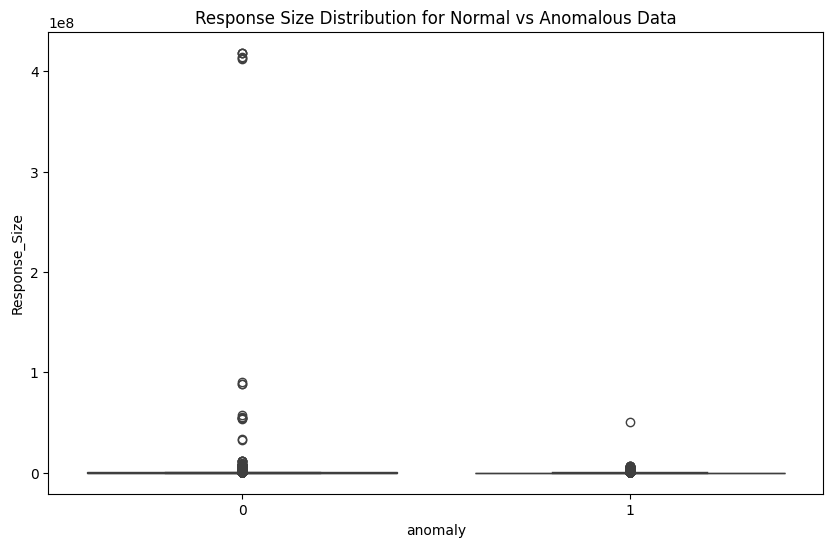

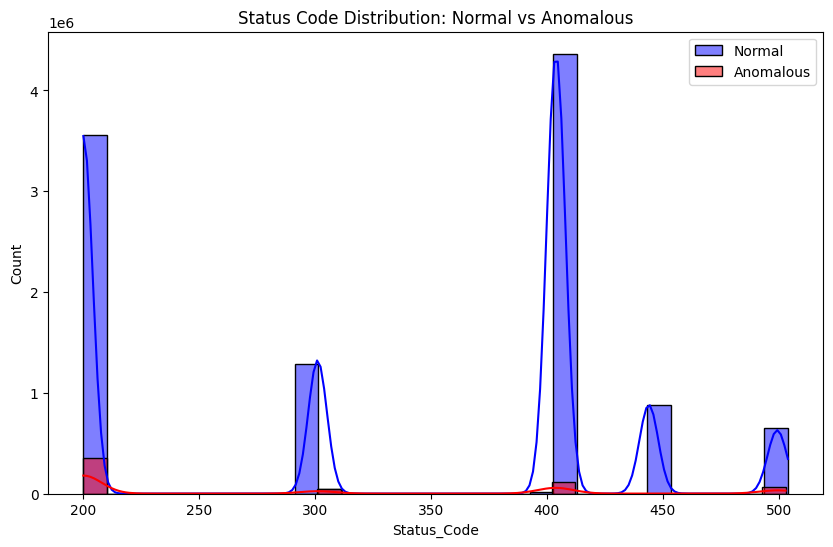

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot to compare response size distribution
plt.figure(figsize=(10, 6))
sns.boxplot(x='anomaly', y='Response_Size', data=df)
plt.title("Response Size Distribution for Normal vs Anomalous Data")
plt.show()

# Histogram for Status Codes
plt.figure(figsize=(10, 6))
sns.histplot(df[df['anomaly'] == 1]['Status_Code'], color='blue', kde=True, label="Normal", bins=30)
sns.histplot(df[df['anomaly'] == 0]['Status_Code'], color='red', kde=True, label="Anomalous", bins=30)
plt.legend()
plt.title("Status Code Distribution: Normal vs Anomalous")
plt.show()

In [43]:
display(
    df[df['Is_Anomaly'] == True][df['Status_Code'] > 200],
    df[(df['Is_Anomaly'] == True) & (df['Status_Code'] > 200)]['IP_Address'].unique()

)

C:\Users\ASUS TUF\AppData\Local\Temp\ipykernel_12708\695714536.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df[df['Is_Anomaly'] == True][df['Status_Code'] > 200],


,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent,Hour,Request_Length,Anomaly,Is_Anomaly,hour,day_of_week,anomaly
25,36803,2022-12-16 17:10:29,1292324,499,0,66668,690880,17,201,-1,True,17,4,1
27,36803,2022-12-16 17:10:32,1292274,499,0,66668,690880,17,211,-1,True,17,4,1
28,36803,2022-12-16 17:10:33,1436253,499,0,176811,690880,17,85,-1,True,17,4,0
45,36803,2022-12-16 17:10:56,1436253,499,0,176811,369111,17,85,-1,True,17,4,1
60,36803,2022-12-16 17:11:17,1436253,499,0,176811,596519,17,85,-1,True,17,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11363635,37296,2024-09-17 00:51:50,555557,301,162,144459,239652,0,14,-1,True,0,1,1
11363645,37296,2024-09-17 00:57:15,555557,301,162,144459,239652,0,14,-1,True,0,1,1
11363691,37296,2024-09-17 03:22:34,716473,404,107781,66668,214260,3,116,-1,True,3,1,1
11363797,37296,2024-09-17 05:02:58,1236051,502,150,66668,236341,5,24,-1,True,5,1,1


array([ 36803, 206269, 164081, ..., 177066, 108339,  37296],
      shape=(16985,))

In [52]:
anomalycase = df[(df['IP_Address'] == 36803) & (df['Is_Anomaly'] == True)]
nonanomalycase = df[(df['IP_Address'] == 36803) & (df['Is_Anomaly'] == False)]

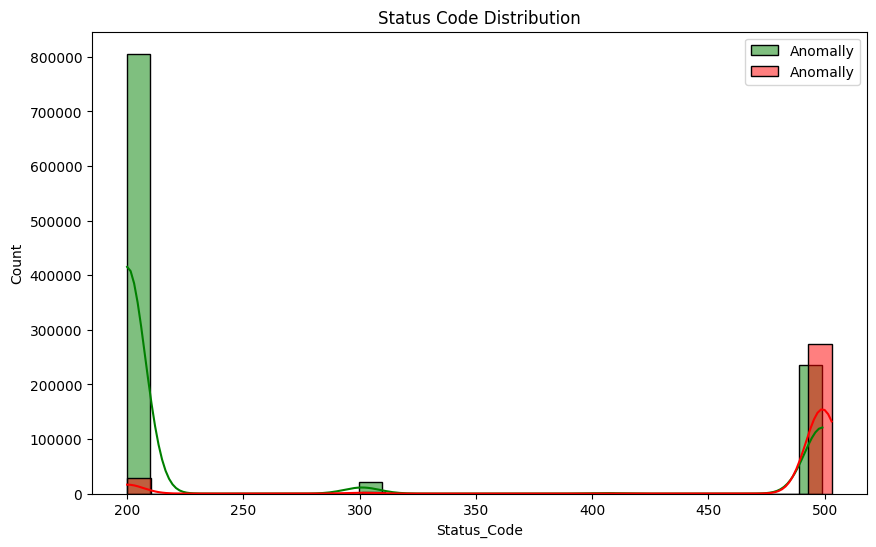

In [54]:
plt.figure(figsize=(10, 6))
sns.histplot(nonanomalycase['Status_Code'], color='green', kde=True, label="Anomally", bins=30)
sns.histplot(anomalycase['Status_Code'], color='red', kde=True, label="Anomally", bins=30)
plt.legend()
plt.title("Status Code Distribution")
plt.show()

In [55]:
df. to_csv('labeled_oldlogs.csv', index=False)

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.under_sampling import RandomUnderSampler
# Load your dataset
# Replace with the path to your CSV file or DataFrame
df = pd.read_csv('labeled_oldlogs.csv')

df



,IP_Address,Timestamp,Request,Status_Code,Response_Size,Referrer,User_Agent,Hour,Request_Length,Anomaly,Is_Anomaly,hour,day_of_week,anomaly
0,15505,2022-12-16 17:04:10,1236051,404,146,66668,236341,17,24,1,False,17,4,1
1,36679,2022-12-16 17:04:12,555557,200,138,66668,236736,17,14,1,False,17,4,1
2,36679,2022-12-16 17:05:16,555557,200,665508,66668,236736,17,14,1,False,17,4,1
3,53626,2022-12-16 17:06:07,555557,200,665508,66668,238454,17,14,1,False,17,4,1
4,53626,2022-12-16 17:06:08,1320396,200,92444,155216,238454,17,86,1,False,17,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11364746,37296,2024-09-17 07:41:14,1236051,200,176,66668,236834,7,24,1,False,7,1,1
11364747,37296,2024-09-17 07:45:28,555557,301,162,144459,239652,7,14,1,False,7,1,1
11364748,37296,2024-09-17 07:50:28,555557,200,138,144459,239652,7,14,1,False,7,1,1
11364749,37296,2024-09-17 07:55:28,1350585,200,0,144459,239652,7,15,1,False,7,1,1


In [66]:
# Define features (X) and target (y)
# Replace 'target_column' with the name of your target column
X = df.loc[:10000].drop(columns=[ 'Anomaly', 'Is_Anomaly', 'anomaly', 'Timestamp'])
y = df.loc[:10000]['anomaly']

# Check class distribution before under-sampling
print("Class distribution before under-sampling:")
print(y.value_counts())

# Perform under-sampling
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X, y)

# Check class distribution after under-sampling
print("\nClass distribution after under-sampling:")
print(pd.Series(y_resampled).value_counts())

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Class distribution before under-sampling:
anomaly
1    8483
0    1518
Name: count, dtype: int64

Class distribution after under-sampling:
anomaly
0    1518
1    1518
Name: count, dtype: int64


In [68]:
# Define multiple machine learning models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

# Train and evaluate each model
results = []

trained_models = {
    "Logistic Regression": '',
    "Random Forest": '',
    "SVM": '',
    "Decision Tree": '',
    "Gradient Boosting": ''
}

for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on the test set
    trained_models[model_name] = model

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Use 'weighted' for multiclass
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Append results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create a DataFrame to display results
results_df = pd.DataFrame(results)

# Display model performance
print("\nModel Performance:")
print(results_df)

# Save the results to a CSV file
results_df.to_csv('model_performance_results.csv', index=False)


Training Logistic Regression...
Training Random Forest...


d:\python\SKC\logsanomaly\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training SVM...
Training Decision Tree...
Training Gradient Boosting...

Model Performance:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.920040   0.917150  0.920040  0.912877
1        Random Forest  0.994003   0.994083  0.994003  0.994026
2                  SVM  0.949525   0.948124  0.949525  0.947808
3        Decision Tree  0.988006   0.988041  0.988006  0.988022
4    Gradient Boosting  0.982509   0.982378  0.982509  0.982307


In [69]:
print(trained_models)

{'Logistic Regression': LogisticRegression(), 'Random Forest': RandomForestClassifier(), 'SVM': SVC(), 'Decision Tree': DecisionTreeClassifier(), 'Gradient Boosting': GradientBoostingClassifier()}


In [70]:
prediction_resuts = []

for model_name, model in models.items():
    y_pred = model.predict(X_test)  # Predict on the test set
    prediction_resuts.append(y_pred)

In [73]:
np.shape(prediction_resuts)

(5, 2001)

In [83]:
from scipy.stats import mode

# Perform majority voting (mode along rows for each column)
final_predictions = mode(prediction_resuts, axis=0)
print(final_predictions[0], len(final_predictions[0]), end='\n\n\n')
final_predictions = final_predictions.mode.flatten()
print(final_predictions)

# Output the shape and a sample of final predictions
print("Shape of Final Predictions:", final_predictions.shape)
print("Sample of Final Predictions:", final_predictions[:10])

accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions, average='weighted')  # Use 'weighted' for multiclass
recall = recall_score(y_test, final_predictions, average='weighted')
f1 = f1_score(y_test, final_predictions, average='weighted')

results2 = []

# Append results
results2.append({
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
})

display(results2)

[1 1 1 ... 0 1 1] 2001


[1 1 1 ... 0 1 1]
Shape of Final Predictions: (2001,)
Sample of Final Predictions: [1 1 1 1 1 1 1 1 1 1]


[{'Accuracy': 0.9865067466266867,
  'Precision': 0.9864471247771534,
  'Recall': 0.9865067466266867,
  'F1 Score': 0.9863698343984433}]